# Chromosome IV Replicate 1 - Prototype Replication Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs


In [3]:
config, _ = load_default_chrom_configs()
config.shift_parameters_for_alpha()

real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1, chr=4)

Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0


In [6]:
# Attempt to fix the gamma2 parameter so G2M takes up the last 0.225 of the cell cycle
real_deconv1.update_parameters({'gamma2': 0.775})
real_deconv1.config.params_dic

{'mu0': -4.790099999999999,
 'delta': 8.1805,
 'sigma0': 10.9885,
 'sigmav': 0.1424,
 'lambda': 68.1914,
 'gamma1': 0.32672132761609235,
 'gamma2': 0.775,
 'halted': 0.2245,
 'alpha': 22}

In [7]:
real_deconv1.setup_deconvolution(real_deconv1.config)
real_deconv1.iterative_deconvolution_updates(1)

Initializing N using config H.
Initializing B using timepoint 0
Iteration 0
0/702 - 00:00:00.003
100/702 - 00:00:00.063
200/702 - 00:00:00.120
300/702 - 00:00:00.183
400/702 - 00:00:00.243
500/702 - 00:00:00.298
600/702 - 00:00:00.355
700/702 - 00:00:00.419
Iteration completed 00:00:00.625, rn=0.005560041977116635


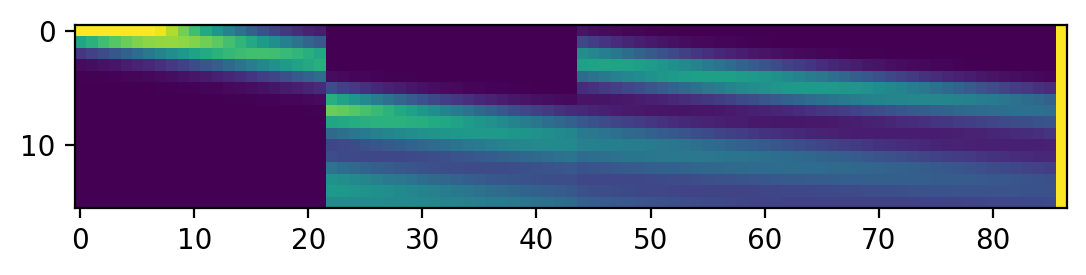

In [8]:
plt.imshow(real_deconv1.config.H, vmax=0.05)

In [9]:
timepoints = config.timepoints
initial_values = config.params_dic

init_params_df = pd.DataFrame(initial_values, index=['value']).T
init_params_df = init_params_df.drop('alpha')
init_params_df

,value
mu0,-4.790100
delta,8.180500
sigma0,10.988500
sigmav,0.142400
lambda,68.191400
gamma1,0.326721
gamma2,0.775000
halted,0.224500


In [11]:
bounds_dic = {
    'mu0': (-30, 30),
    'lambda': (60, 80),
    'delta': (0, 24),
    'sigma0': (1, 14),
    'sigmav': (0.01, 1.),
    'gamma1': (0., 1.),
    'gamma2': (config.params_dic['gamma2'], config.params_dic['gamma2']),
    'halted': (0.0, 1.),
}

bounds_params_df = pd.DataFrame(bounds_dic, index=['min', 'max']).T
params_df = init_params_df.join(bounds_params_df)
params_df


,value,min,max
mu0,-4.790100,-30.000,30.000
delta,8.180500,0.000,24.000
sigma0,10.988500,1.000,14.000
sigmav,0.142400,0.010,1.000
lambda,68.191400,60.000,80.000
gamma1,0.326721,0.000,1.000
gamma2,0.775000,0.775,0.775
halted,0.224500,0.000,1.000


In [12]:
real_deconv1.setup_deconvolution(real_deconv1.config)

Initializing N using config H.
Initializing B using timepoint 0


In [13]:
real_deconv1.iterative_deconvolution_updates(20)

Iteration 0
0/702 - 00:00:00.054
100/702 - 00:00:00.109
200/702 - 00:00:00.163
300/702 - 00:00:00.216
400/702 - 00:00:00.268
500/702 - 00:00:00.321
600/702 - 00:00:00.372
700/702 - 00:00:00.424
Iteration completed 00:00:00.588, rn=0.005560041977116635
Iteration 1
0/702 - 00:00:00.590
100/702 - 00:00:00.646
200/702 - 00:00:00.701
300/702 - 00:00:00.759
400/702 - 00:00:00.814
500/702 - 00:00:00.870
600/702 - 00:00:00.925
700/702 - 00:00:00.979
Iteration completed 00:00:01.155, rn=0.0045979610632629125
Iteration 2
0/702 - 00:00:01.157
100/702 - 00:00:01.230
200/702 - 00:00:01.284
300/702 - 00:00:01.339
400/702 - 00:00:01.414
500/702 - 00:00:01.496
600/702 - 00:00:01.549
700/702 - 00:00:01.626
Iteration completed 00:00:01.758, rn=0.0042327876416538655
Iteration 3
0/702 - 00:00:01.760
100/702 - 00:00:01.815
200/702 - 00:00:01.869
300/702 - 00:00:01.927
400/702 - 00:00:01.983
500/702 - 00:00:02.037
600/702 - 00:00:02.091
700/702 - 00:00:02.146
Iteration completed 00:00:02.434, rn=0.004046264

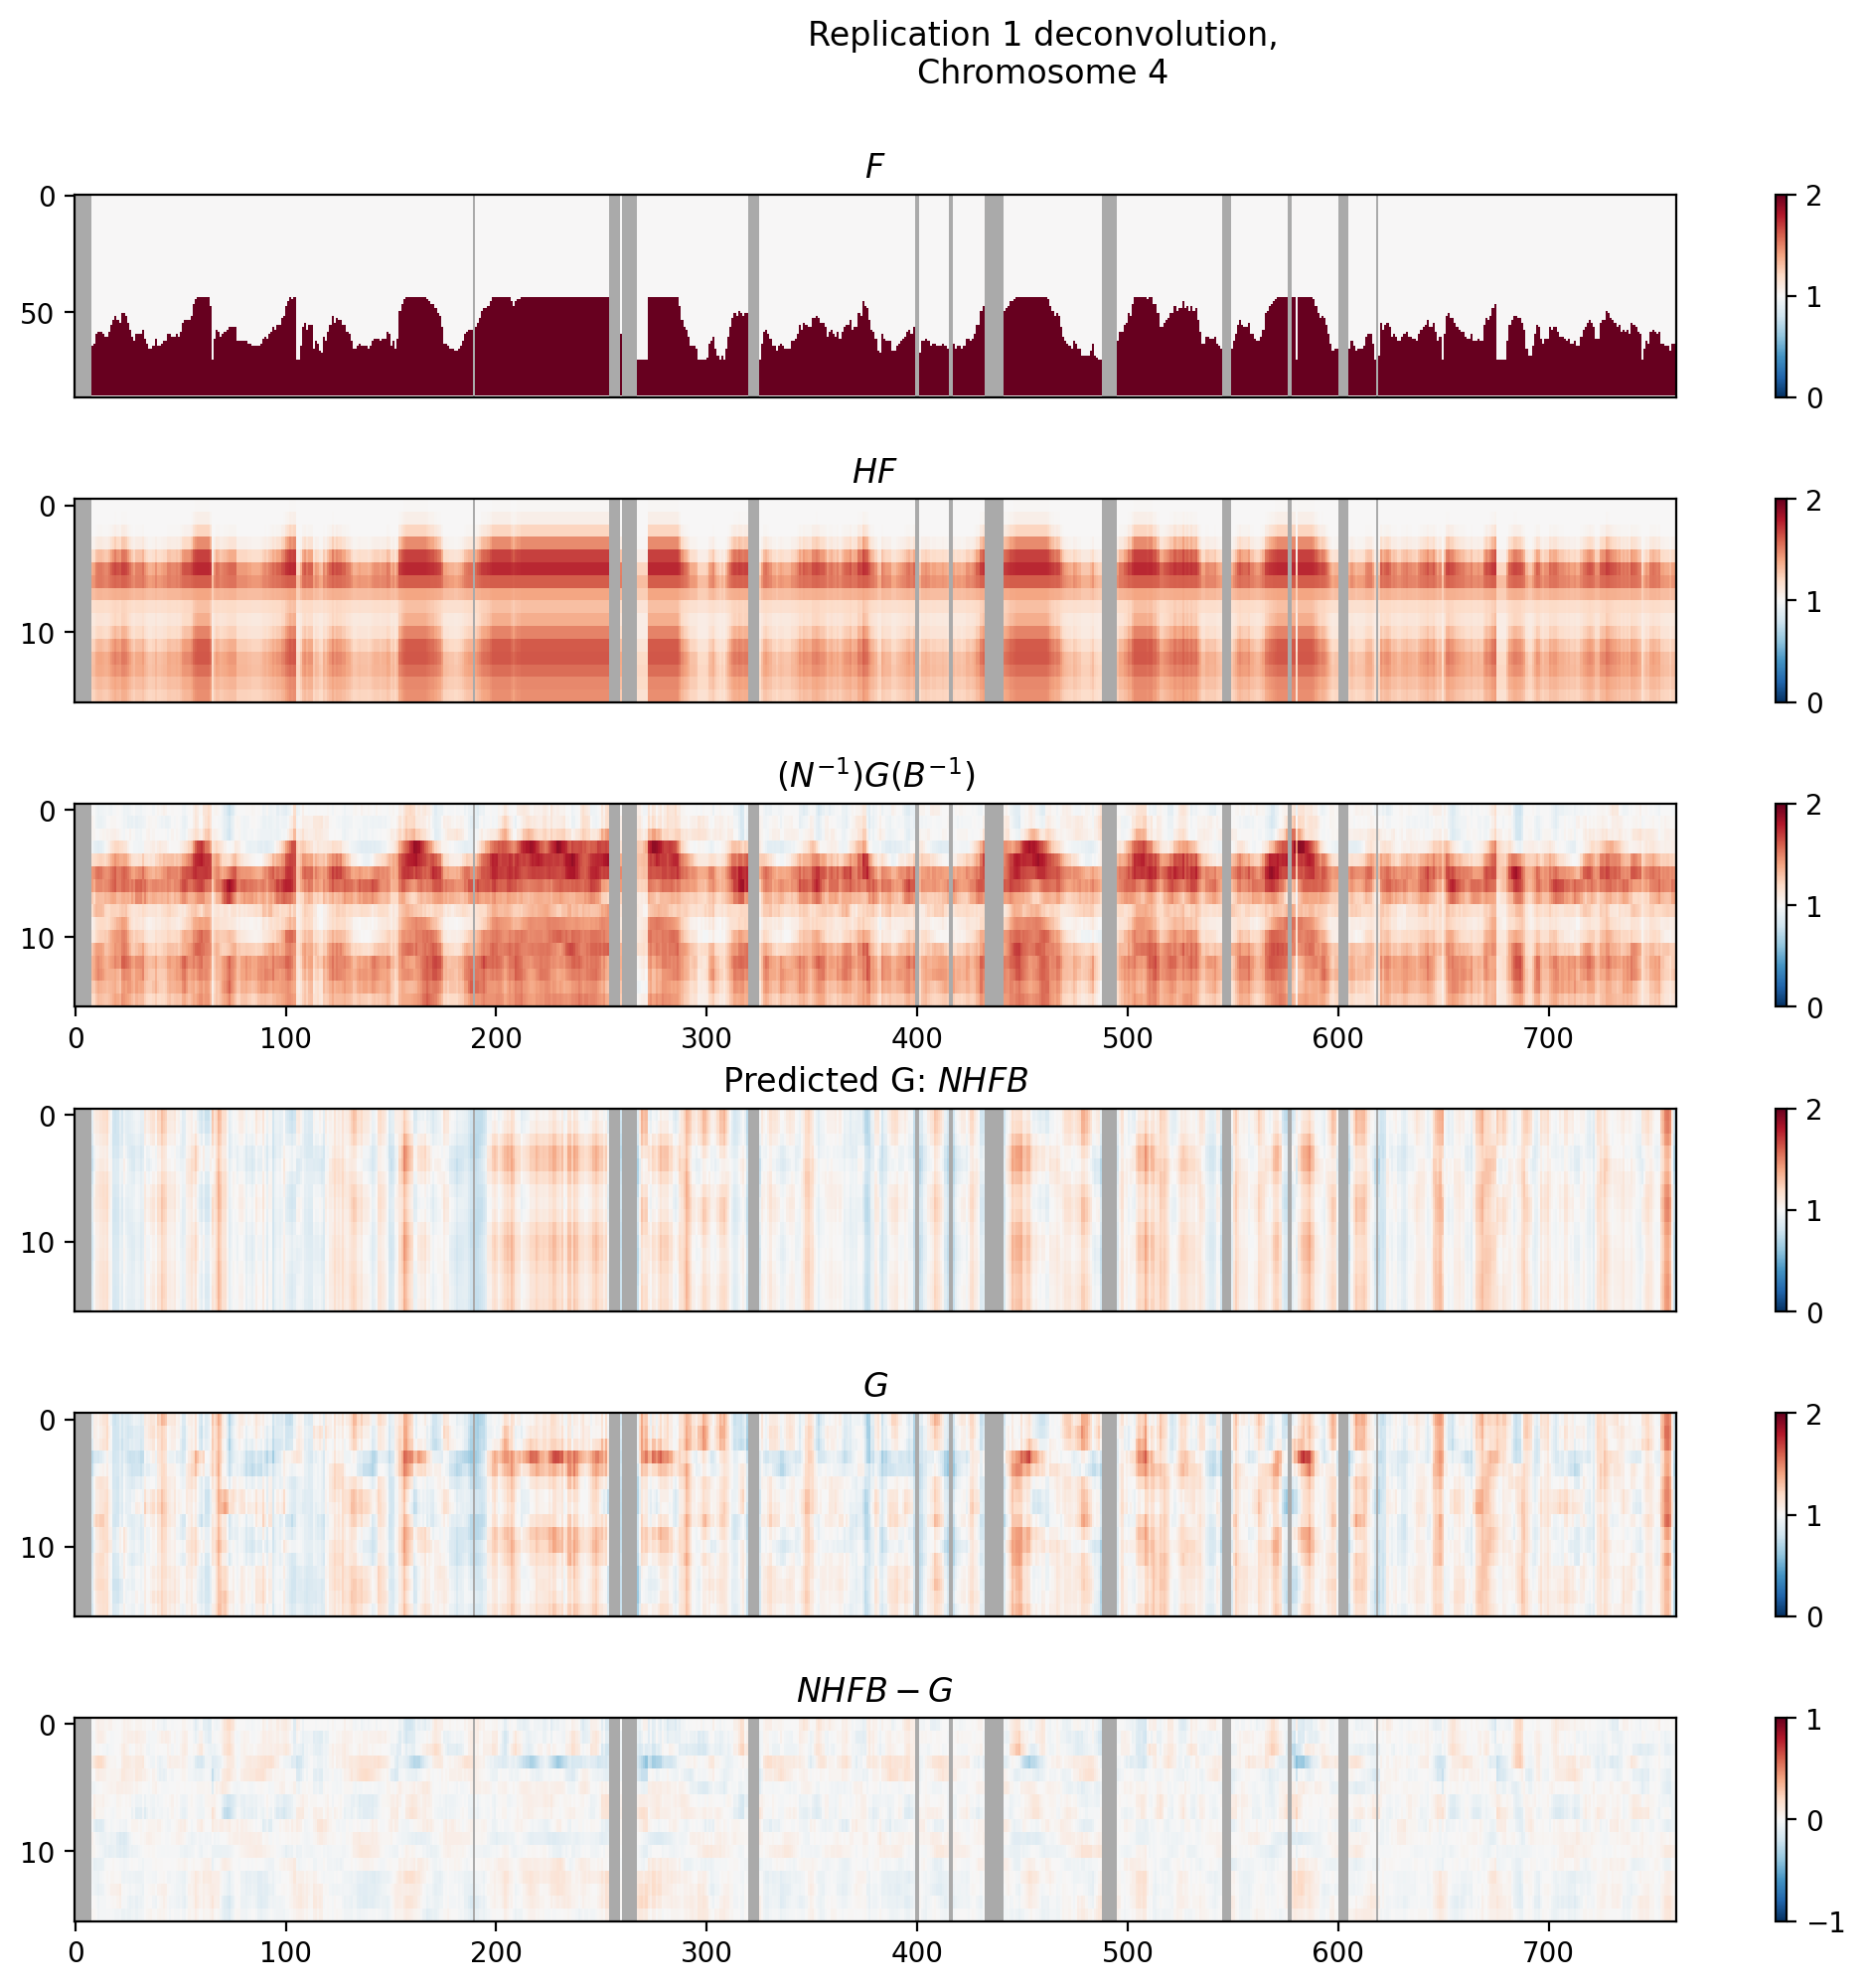

In [14]:
real_deconv1.plot_heatmaps()

In [16]:
from src.optimize_H import ParameterOptimizer

optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv1.N,
    F=real_deconv1.F,
    B=real_deconv1.B,
    G=real_deconv1.G
)


In [17]:
from src.timer import Timer

timer = Timer()

num_epochs = 1000
num_iterations_N_B = 5
update_params_df = pd.DataFrame()

N = real_deconv1.N
B = real_deconv1.B

optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv1.N,
    F=real_deconv1.F,
    B=real_deconv1.B,
    G=real_deconv1.G
)

for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    
    optimizer.optimize(maxiter=1000, verbose=True)

    real_deconv1.H = optimizer.current_H
        
    real_deconv1.iterative_deconvolution_updates(
        total_iterations=num_iterations_N_B, timer=timer,
        initial_B=B, initial_N=N)
    timer.print_time()
    
    params_row = pd.DataFrame([optimizer.params_df['value']], index=[epoch])
    params_row['opt_H_loss'] = optimizer.rn
    params_row['F_rn'] = real_deconv1.rn

    update_params_df = pd.concat([update_params_df, params_row])
    
    optimizer.N = real_deconv1.N
    optimizer.B = real_deconv1.B
    optimizer.F = real_deconv1.F
    
    N = real_deconv1.N
    B = real_deconv1.B

    print(update_params_df.iloc[-1])


Epoch:  0
Optimization [1]: Current loss: 0.003821768082497895
Optimization [101]: Current loss: 0.003723398170488199
Optimization [201]: Current loss: 0.003711567787387575
Optimization [301]: Current loss: 0.0037109525188071973
Optimization [401]: Current loss: 0.003700386820357245
Optimization [501]: Current loss: 0.003699019729735819
Optimization [601]: Current loss: 0.003699009162602943
Optimization terminated successfully.
         Current function value: 0.003699
         Iterations: 439
         Function evaluations: 661
Iteration 0
0/702 - 00:02:54.301
100/702 - 00:02:54.355
200/702 - 00:02:54.411
300/702 - 00:02:54.465
400/702 - 00:02:54.519
500/702 - 00:02:54.574
600/702 - 00:02:54.629
700/702 - 00:02:54.682
Iteration completed 00:02:54.896, rn=0.0036795418038669796
Iteration 1
0/702 - 00:02:54.897
100/702 - 00:02:54.951
200/702 - 00:02:55.006
300/702 - 00:02:55.060
400/702 - 00:02:55.113
500/702 - 00:02:55.167
600/702 - 00:02:55.221
700/702 - 00:02:55.275
Iteration completed

300/702 - 00:08:58.892
400/702 - 00:08:58.950
500/702 - 00:08:59.004
600/702 - 00:08:59.058
700/702 - 00:08:59.113
Iteration completed 00:08:59.866, rn=0.0033537182805051884
Iteration 1
0/702 - 00:08:59.868
100/702 - 00:08:59.935
200/702 - 00:08:59.991
300/702 - 00:09:00.044
400/702 - 00:09:00.101
500/702 - 00:09:00.156
600/702 - 00:09:00.211
700/702 - 00:09:00.265
Iteration completed 00:09:00.508, rn=0.0033445843449706
Iteration 2
0/702 - 00:09:00.509
100/702 - 00:09:00.563
200/702 - 00:09:00.618
300/702 - 00:09:00.672
400/702 - 00:09:00.726
500/702 - 00:09:00.784
600/702 - 00:09:00.843
700/702 - 00:09:00.899
Iteration completed 00:09:01.340, rn=0.003343259155726701
Iteration 3
0/702 - 00:09:01.342
100/702 - 00:09:01.397
200/702 - 00:09:01.451
300/702 - 00:09:01.506
400/702 - 00:09:01.560
500/702 - 00:09:01.615
600/702 - 00:09:01.671
700/702 - 00:09:01.727
Iteration completed 00:09:02.161, rn=0.0033429664782870508
Iteration 4
0/702 - 00:09:02.162
100/702 - 00:09:02.216
200/702 - 00:09

100/702 - 00:12:53.564
200/702 - 00:12:53.618
300/702 - 00:12:53.673
400/702 - 00:12:53.728
500/702 - 00:12:53.782
600/702 - 00:12:53.835
700/702 - 00:12:53.889
Iteration completed 00:12:55.205, rn=0.003256267780976117
00:12:55.205
mu0            1.199244
lambda        70.336891
delta          0.000442
sigma0         5.359491
sigmav         0.173715
gamma1         0.365568
gamma2         0.775000
halted         0.169475
opt_H_loss     0.003267
F_rn           0.003256
Name: 8, dtype: float64
Epoch:  9
Optimization [1]: Current loss: 0.0032562677809761164
Optimization [101]: Current loss: 0.003245737281921072
Optimization terminated successfully.
         Current function value: 0.003245
         Iterations: 106
         Function evaluations: 180
Iteration 0
0/702 - 00:13:40.729
100/702 - 00:13:40.791
200/702 - 00:13:40.849
300/702 - 00:13:40.901
400/702 - 00:13:40.953
500/702 - 00:13:41.005
600/702 - 00:13:41.060
700/702 - 00:13:41.122
Iteration completed 00:13:42.047, rn=0.003253107986

100/702 - 00:17:52.693
200/702 - 00:17:52.745
300/702 - 00:17:52.798
400/702 - 00:17:52.850
500/702 - 00:17:52.902
600/702 - 00:17:52.954
700/702 - 00:17:53.005
Iteration completed 00:17:53.524, rn=0.003180633383639823
Iteration 1
0/702 - 00:17:53.525
100/702 - 00:17:53.578
200/702 - 00:17:53.630
300/702 - 00:17:53.682
400/702 - 00:17:53.733
500/702 - 00:17:53.787
600/702 - 00:17:53.840
700/702 - 00:17:53.892
Iteration completed 00:17:54.619, rn=0.0031776249493513224
Iteration 2
0/702 - 00:17:54.620
100/702 - 00:17:54.673
200/702 - 00:17:54.725
300/702 - 00:17:54.776
400/702 - 00:17:54.828
500/702 - 00:17:54.880
600/702 - 00:17:54.932
700/702 - 00:17:54.983
Iteration completed 00:17:55.716, rn=0.0031759538318053625
Iteration 3
0/702 - 00:17:55.717
100/702 - 00:17:55.769
200/702 - 00:17:55.822
300/702 - 00:17:55.875
400/702 - 00:17:55.927
500/702 - 00:17:55.980
600/702 - 00:17:56.031
700/702 - 00:17:56.085
Iteration completed 00:17:56.787, rn=0.0031751837153142655
Iteration 4
0/702 - 00

700/702 - 00:21:39.652
Iteration completed 00:21:40.437, rn=0.0031031807444769632
Iteration 4
0/702 - 00:21:40.439
100/702 - 00:21:40.511
200/702 - 00:21:40.570
300/702 - 00:21:40.623
400/702 - 00:21:40.686
500/702 - 00:21:40.751
600/702 - 00:21:40.816
700/702 - 00:21:40.878
Iteration completed 00:21:41.200, rn=0.003099652159467601
00:21:41.200
mu0            1.578353
lambda        67.961667
delta          0.001295
sigma0         6.510676
sigmav         0.149494
gamma1         0.398945
gamma2         0.775000
halted         0.004446
opt_H_loss     0.003120
F_rn           0.003100
Name: 17, dtype: float64
Epoch:  18
Optimization [1]: Current loss: 0.003099652159467602
Optimization [101]: Current loss: 0.0030939217038304964
Optimization [201]: Current loss: 0.0030932989263736436
Optimization terminated successfully.
         Current function value: 0.003093
         Iterations: 151
         Function evaluations: 234
Iteration 0
0/702 - 00:22:40.856
100/702 - 00:22:40.908
200/702 - 00:22:

...

100/702 - 08:33:19.400
200/702 - 08:33:19.443
300/702 - 08:33:19.485
400/702 - 08:33:19.528
500/702 - 08:33:19.570
600/702 - 08:33:19.612
700/702 - 08:33:19.654
Iteration completed 08:33:19.830, rn=0.002939049654002846
Iteration 3
0/702 - 08:33:19.831
100/702 - 08:33:19.874
200/702 - 08:33:19.917
300/702 - 08:33:19.960
400/702 - 08:33:20.002
500/702 - 08:33:20.045
600/702 - 08:33:20.087
700/702 - 08:33:20.129
Iteration completed 08:33:20.575, rn=0.0029390496540056144
Iteration 4
0/702 - 08:33:20.576
100/702 - 08:33:20.618
200/702 - 08:33:20.661
300/702 - 08:33:20.703
400/702 - 08:33:20.745
500/702 - 08:33:20.788
600/702 - 08:33:20.830
700/702 - 08:33:20.871
Iteration completed 08:33:21.364, rn=0.0029390496540056153
08:33:21.364
mu0            5.806372
lambda        60.744978
delta         13.960133
sigma0         5.714818
sigmav         0.029094
gamma1         0.530114
gamma2         0.775000
halted         0.000023
opt_H_loss     0.002939
F_rn           0.002939
Name: 979, dtype: floa

100/702 - 08:35:20.669
200/702 - 08:35:20.712
300/702 - 08:35:20.754
400/702 - 08:35:20.797
500/702 - 08:35:20.839
600/702 - 08:35:20.881
700/702 - 08:35:20.922
Iteration completed 08:35:21.200, rn=0.0029391588124046074
Iteration 1
0/702 - 08:35:21.201
100/702 - 08:35:21.244
200/702 - 08:35:21.286
300/702 - 08:35:21.328
400/702 - 08:35:21.370
500/702 - 08:35:21.412
600/702 - 08:35:21.454
700/702 - 08:35:21.496
Iteration completed 08:35:21.699, rn=0.0029391127281705467
Iteration 2
0/702 - 08:35:21.700
100/702 - 08:35:21.743
200/702 - 08:35:21.786
300/702 - 08:35:21.829
400/702 - 08:35:21.871
500/702 - 08:35:21.914
600/702 - 08:35:21.956
700/702 - 08:35:21.997
Iteration completed 08:35:22.085, rn=0.0029391121095533896
Iteration 3
0/702 - 08:35:22.086
100/702 - 08:35:22.129
200/702 - 08:35:22.171
300/702 - 08:35:22.214
400/702 - 08:35:22.256
500/702 - 08:35:22.299
600/702 - 08:35:22.341
700/702 - 08:35:22.383
Iteration completed 08:35:22.520, rn=0.002939112109449063
Iteration 4
0/702 - 08

Iteration completed 08:37:02.689, rn=0.0029392216136059023
08:37:02.690
mu0            5.811828
lambda        60.747655
delta         13.968476
sigma0         5.715245
sigmav         0.029011
gamma1         0.530143
gamma2         0.775000
halted         0.000027
opt_H_loss     0.002939
F_rn           0.002939
Name: 988, dtype: float64
Epoch:  989
Optimization [1]: Current loss: 0.002939221613605901
Optimization terminated successfully.
         Current function value: 0.002939
         Iterations: 51
         Function evaluations: 98
Iteration 0
0/702 - 08:37:25.125
100/702 - 08:37:25.177
200/702 - 08:37:25.223
300/702 - 08:37:25.266
400/702 - 08:37:25.308
500/702 - 08:37:25.351
600/702 - 08:37:25.393
700/702 - 08:37:25.435
Iteration completed 08:37:25.877, rn=0.0029392226086131937
Iteration 1
0/702 - 08:37:25.878
100/702 - 08:37:25.922
200/702 - 08:37:25.966
300/702 - 08:37:26.009
400/702 - 08:37:26.051
500/702 - 08:37:26.093
600/702 - 08:37:26.135
700/702 - 08:37:26.177
Iteration co

500/702 - 08:39:01.648
600/702 - 08:39:01.690
700/702 - 08:39:01.732
Iteration completed 08:39:02.182, rn=0.002938984413307704
Iteration 3
0/702 - 08:39:02.183
100/702 - 08:39:02.225
200/702 - 08:39:02.268
300/702 - 08:39:02.310
400/702 - 08:39:02.352
500/702 - 08:39:02.395
600/702 - 08:39:02.438
700/702 - 08:39:02.480
Iteration completed 08:39:02.603, rn=0.0029389844132655437
Iteration 4
0/702 - 08:39:02.605
100/702 - 08:39:02.647
200/702 - 08:39:02.689
300/702 - 08:39:02.731
400/702 - 08:39:02.773
500/702 - 08:39:02.815
600/702 - 08:39:02.858
700/702 - 08:39:02.900
Iteration completed 08:39:03.126, rn=0.0029389844132655363
08:39:03.126
mu0            5.813394
lambda        60.755824
delta         13.961080
sigma0         5.717469
sigmav         0.029308
gamma1         0.530068
gamma2         0.775000
halted         0.000029
opt_H_loss     0.002939
F_rn           0.002939
Name: 993, dtype: float64
Epoch:  994
Optimization [1]: Current loss: 0.0029389844132655368
Optimization terminate

100/702 - 08:41:03.015
200/702 - 08:41:03.058
300/702 - 08:41:03.100
400/702 - 08:41:03.142
500/702 - 08:41:03.185
600/702 - 08:41:03.228
700/702 - 08:41:03.270
Iteration completed 08:41:03.405, rn=0.0029389842468309437
Iteration 1
0/702 - 08:41:03.406
100/702 - 08:41:03.449
200/702 - 08:41:03.491
300/702 - 08:41:03.533
400/702 - 08:41:03.576
500/702 - 08:41:03.618
600/702 - 08:41:03.660
700/702 - 08:41:03.702
Iteration completed 08:41:03.994, rn=0.0029391412024734713
Iteration 2
0/702 - 08:41:03.995
100/702 - 08:41:04.037
200/702 - 08:41:04.080
300/702 - 08:41:04.123
400/702 - 08:41:04.165
500/702 - 08:41:04.208
600/702 - 08:41:04.250
700/702 - 08:41:04.293
Iteration completed 08:41:04.430, rn=0.002939141357172433
Iteration 3
0/702 - 08:41:04.431
100/702 - 08:41:04.476
200/702 - 08:41:04.521
300/702 - 08:41:04.565
400/702 - 08:41:04.609
500/702 - 08:41:04.651
600/702 - 08:41:04.693
700/702 - 08:41:04.735
Iteration completed 08:41:04.857, rn=0.002939141357201136
Iteration 4
0/702 - 08:

Text(0.5, 0.98, 'Cell cycle parameter updates, 1000 epochs')

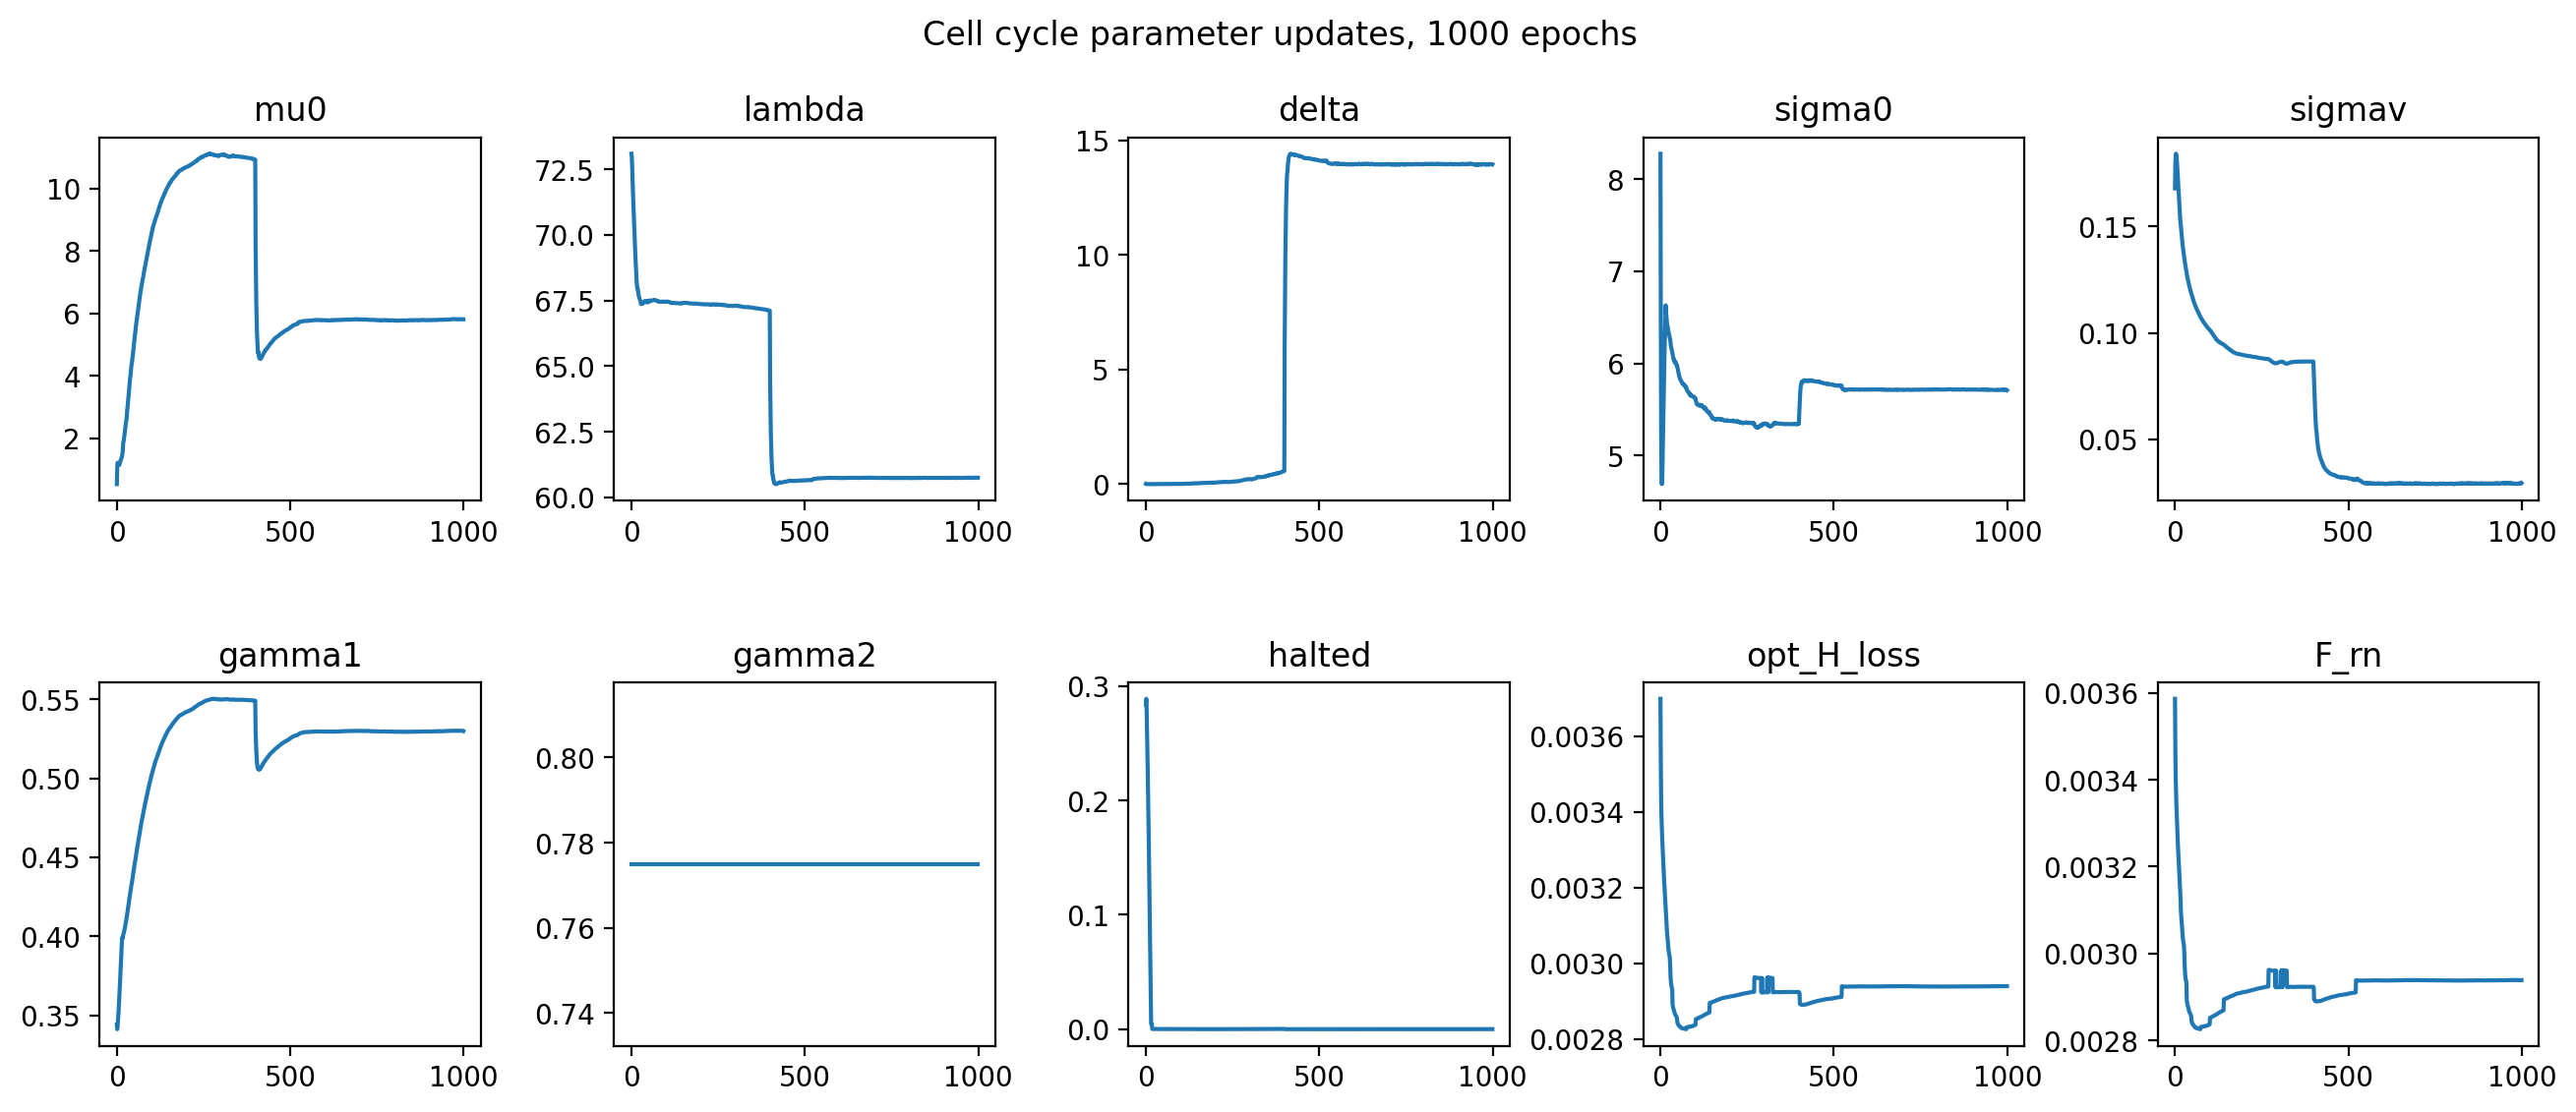

In [18]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(update_params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(update_params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle(f"Cell cycle parameter updates, {num_epochs} epochs")

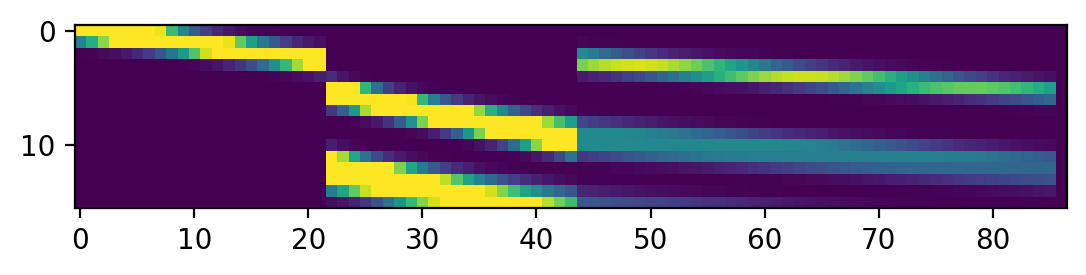

In [19]:
plt.imshow(real_deconv1.H, vmax=0.05)

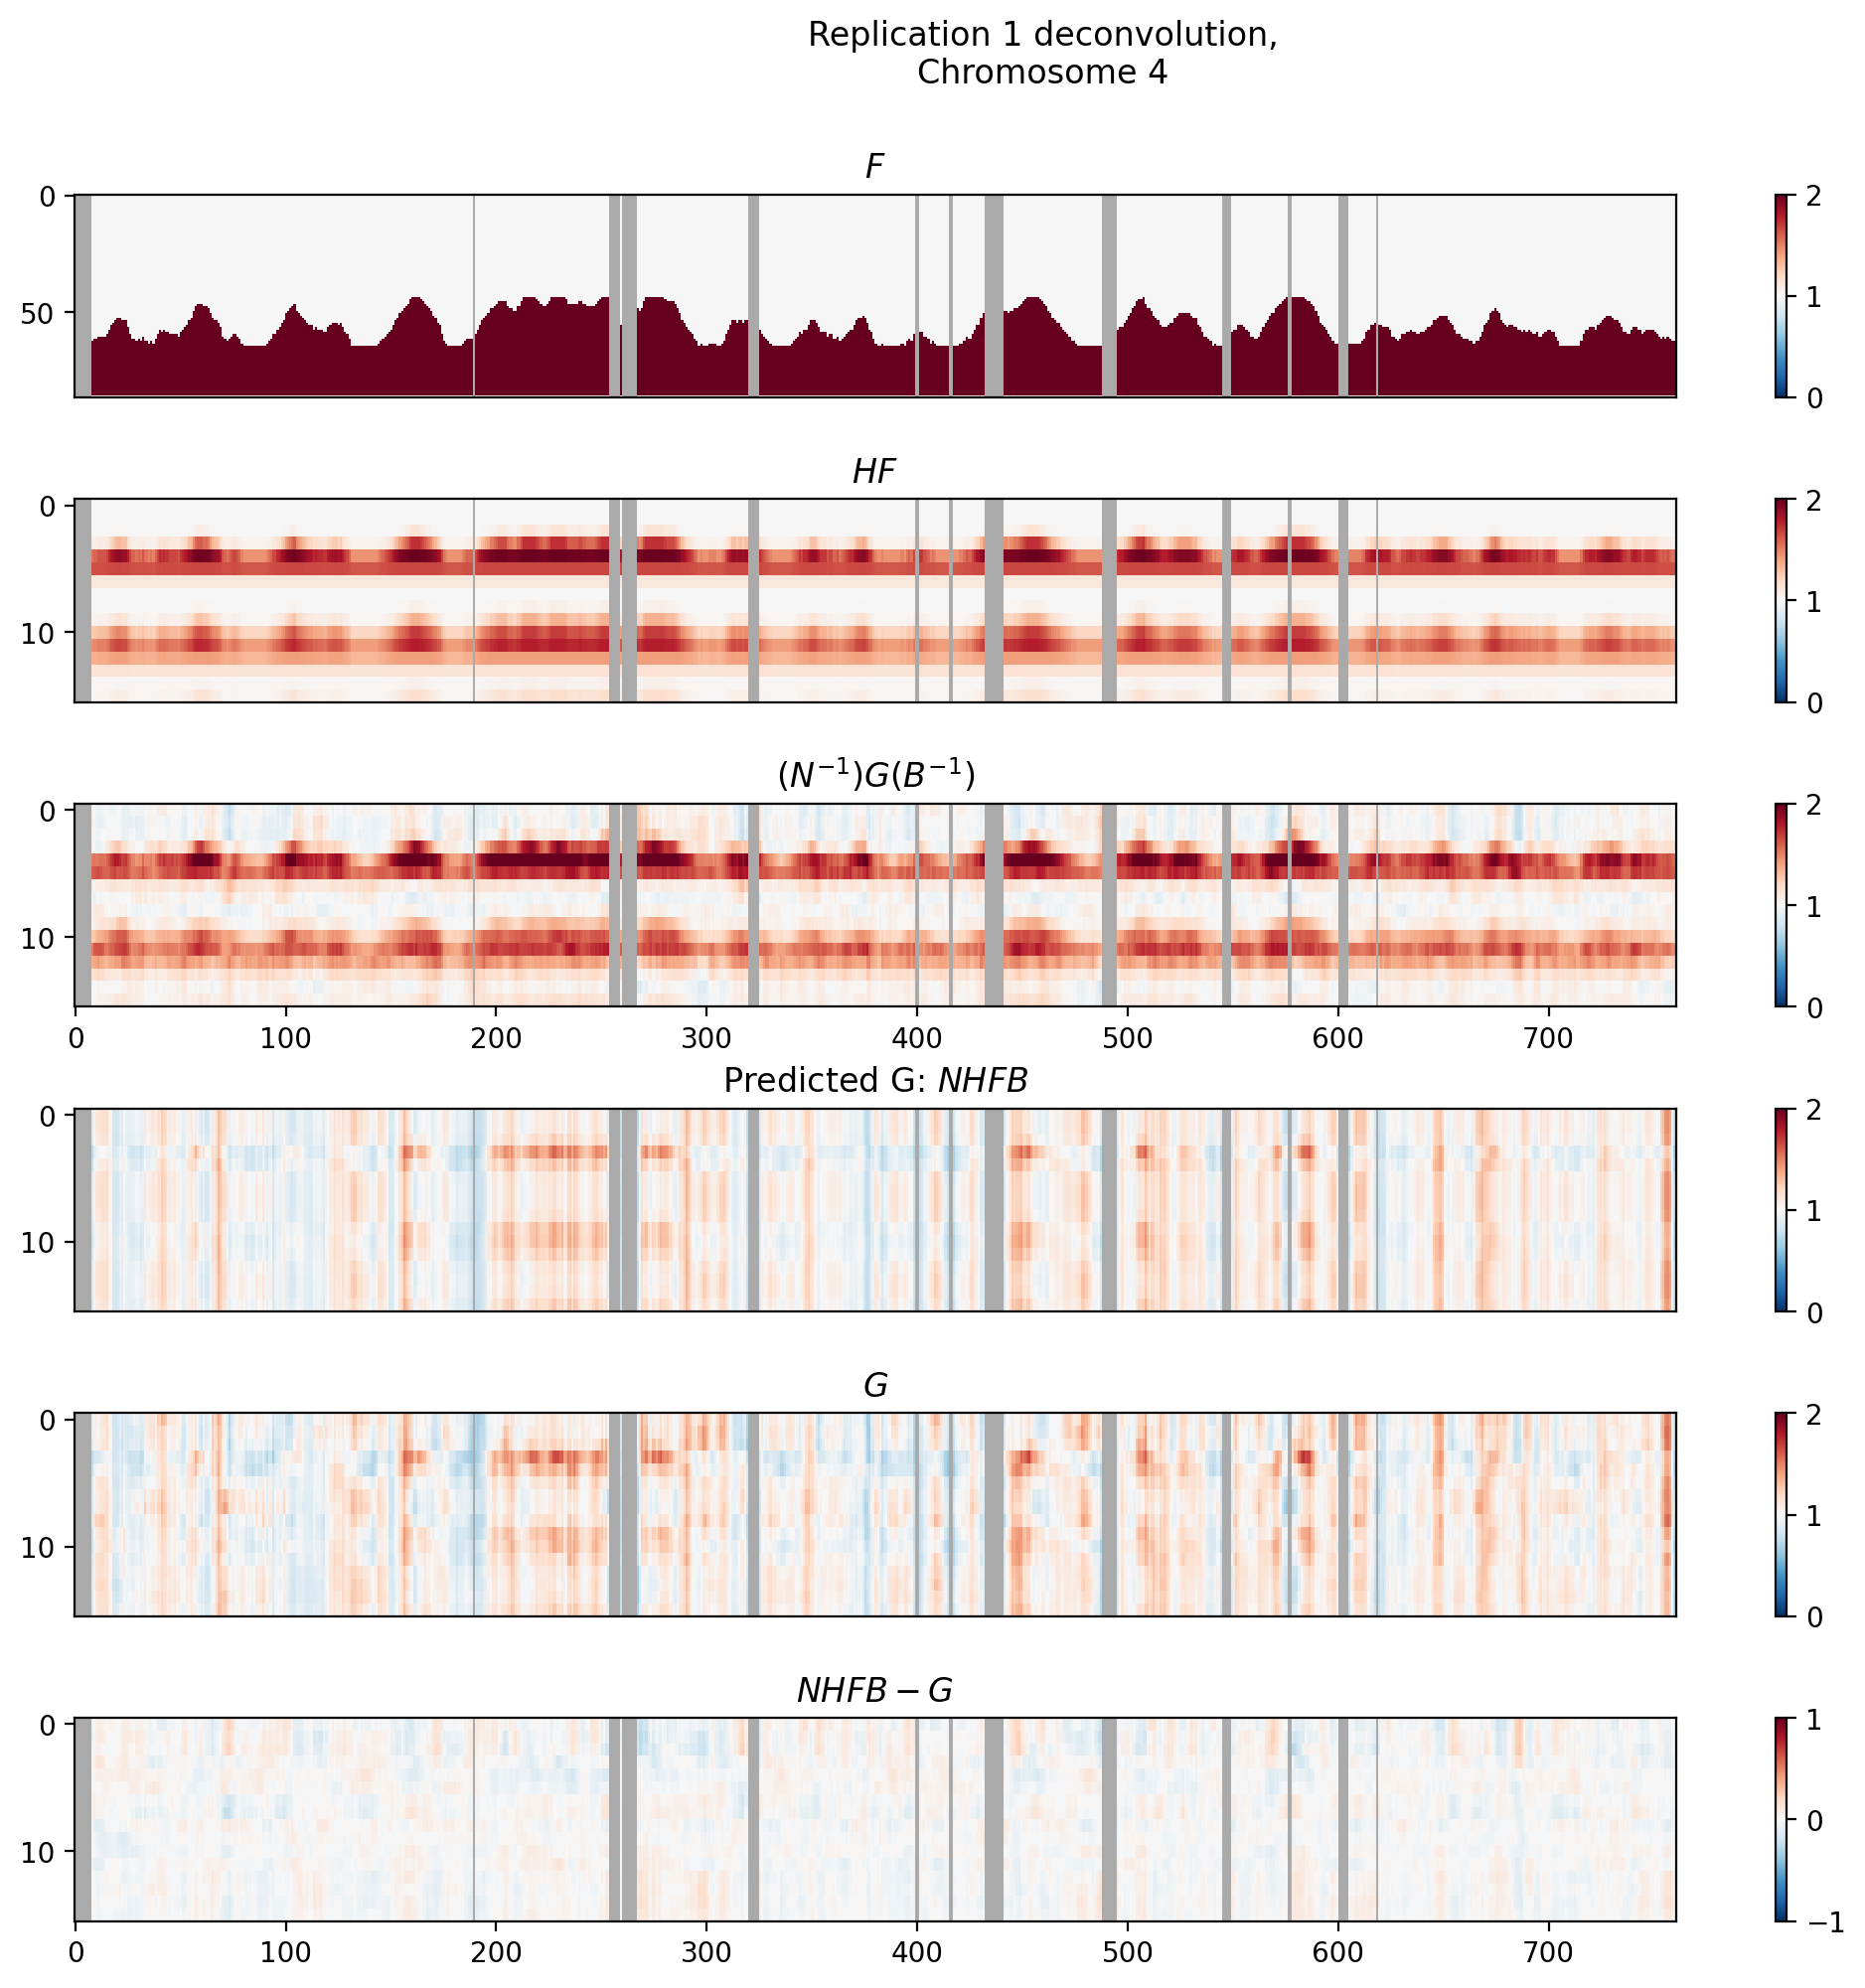

In [20]:
real_deconv1.plot_heatmaps()

In [21]:
config.params_dic

{'mu0': 5.810155531222165,
 'delta': 13.961355587766995,
 'sigma0': 5.710962699070599,
 'sigmav': 0.029429437091128136,
 'lambda': 60.75385243876731,
 'gamma1': 0.529952878473511,
 'gamma2': 0.775,
 'halted': 3.166877634715231e-05,
 'alpha': 22}

Text(0.5, 0.98, 'Average single cell copy number, replicate 1, chrIV')

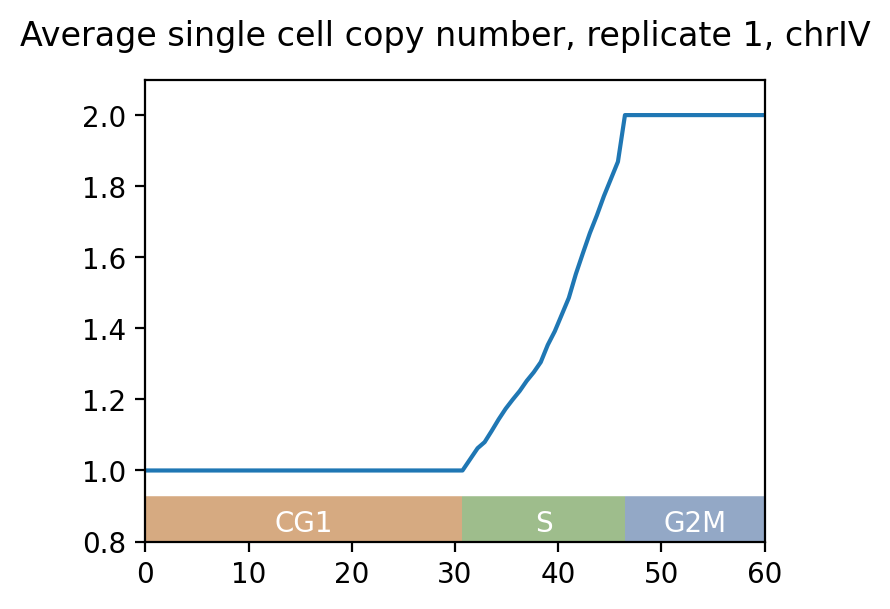

In [22]:
from src.chromatin_model import draw_phase_label_annotations
config = real_deconv1.config

fig = plt.figure(figsize=(4, 3))
t_indices = config.get_Hpositions_for_branch('t')
t_tps = config.get_timepoints_for_branch('t')
plt.plot(t_tps, real_deconv1.F.mean(axis=1)[t_indices])
draw_phase_label_annotations(plt.gca(), config, flip=True, annotations_x=0.85)
plt.xlim(t_tps[0], t_tps[-1])
plt.ylim(0.8, 2.1)
plt.suptitle("Average single cell copy number, replicate 1, chrIV")
